In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, BertModel
from sklearn.model_selection import train_test_split
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [3]:
# Only if using Google Colab

# from google.colab import files
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
THRESHOLD = 0.73 # previously 0.6, changed when we got rid of dupes from training process

## 1. Relevance classifier

Note, we now read lgbtq dataframe in from matched_lgbtq_bills_with_duplicates.csv (from the updated 03_bills_data_prep_eda.ipynb), rather than matched_lgbtq_bills.csv. That's because the matching method with the ACLU datasets accidentally yielded multiple matches in the legiscan database according to bill_number, year, and state—meaning potentially irrelevant bills were getting drawn in to contaminate our model's training set. Now, we read in matched_lgbtq_bills_with_duplicates.csv before explicitly DROPPING all duplicate rows from this dataframe, allowing us to have an uncontaminated training/testing set.

We then reclassify those dropped rows using our own Legal-BERT model later in this notebook, allowing us to save as a final matched_lgbtq_bills.csv file.

In [6]:
# Positive: your matched LGBTQ+ bills
lgbtq = pd.read_csv('../../datasources/final-outputs/matched_lgbtq_bills_with_duplicates.csv')
# lgbtq = pd.read_csv('/content/drive/MyDrive/capstone_personal/matched_lgbtq_bills_with_duplicates.csv') # (changed file path slightly)

# Negative: random sample from unmatched LegiScan bills
all_bills = pd.read_csv('../../datasources/legiscan-joined-all/all_bills_2021_2026.csv',
    engine='python', # ishanis edits
    on_bad_lines='skip',) # ishanis edits — added b/c of error below
    # ParserError: Error tokenizing data. C error: Expected 27 fields in line 70638, saw 29

print(f"lgbtq shape: {lgbtq.shape}")
print(f"all_bills shape: {all_bills.shape}")

lgbtq shape: (2310, 42)
all_bills shape: (746696, 28)


In [7]:
all_bills['year'] = pd.to_datetime(all_bills['status_date']).dt.year
all_bills['year'] = all_bills['year'].fillna(all_bills['year']).astype('Int64')

all_bills['text'] = all_bills['title'].fillna('') + '. ' + all_bills['description'].fillna('')

In [8]:
# get bill text (early?)
lgbtq = lgbtq.merge(
    all_bills[['bill_id', 'text']].drop_duplicates(subset='bill_id'),
    on='bill_id',
    how='left'
)

In [9]:
for col in ['year', 'bill_number', 'bill_id', 'state']:
    print(f"{col}: {lgbtq[col].isna().sum()} NaNs")

year: 3 NaNs
bill_number: 0 NaNs
bill_id: 0 NaNs
state: 0 NaNs


In [10]:
print(all_bills['text'].isna().sum())
print(all_bills['text'].dtype)
print(all_bills['text'].head(10).tolist())

0
object
['Audit Of Cares Act Funds. An Act providing for audits of CARES Act funds expended for the community assistance program and direct grants to municipalities and communities.', 'Minimum Age To Sell Tobacco/nicotine. An Act relating to the minimum age of persons allowed to sell cigarettes, cigars, tobacco, electronic smoking products, products containing nicotine, or products containing tobacco.', 'Definition Of "disaster": Cybersecurity. An Act relating to the definition of &#39;disaster.&#39;', 'Business/prof. License Immunity Covid-19. An Act providing immunity from liability and disciplinary action for occupational licensees for exposure of clients to COVID-19; providing immunity from liability for persons engaging in business and their employees for exposure of customers to COVID-19; and providing for an effective date.', 'Sexual Assault; Def. Of "consent". An Act relating to sexual abuse of a minor; relating to sexual assault; relating to the code of military justice; rela

New: removing duplicate rows before training.

In [11]:
# Save copies of original dataframes
lgbtq_original = lgbtq.copy()
all_bills_original = all_bills.copy()

# Isolate duplicate rows in lgbtq (keeping all occurrences)
lgbtq_duplicates = lgbtq[lgbtq.duplicated(subset=['bill_number', 'year', 'state'], keep=False)]

# Remove duplicate rows in lgbtq based on bill_number, year, and state
lgbtq = lgbtq.drop_duplicates(subset=['bill_number', 'year', 'state'])

# Create a set of (bill_number, year, state) tuples from the cleaned lgbtq df
lgbtq_keys = set(zip(lgbtq['bill_number'], lgbtq['year'], lgbtq['state']))

# Remove matching bills from all_bills
mask = ~pd.Series(zip(all_bills['bill_number'], all_bills['year'], all_bills['state'])).isin(lgbtq_keys)
all_bills = all_bills[mask].reset_index(drop=True)

print(f"lgbtq_original shape: {lgbtq_original.shape}")
print(f"lgbtq shape (deduplicated): {lgbtq.shape}")
print(f"lgbtq_duplicates shape: {lgbtq_duplicates.shape}")
print(f"all_bills_original shape: {all_bills_original.shape}")
print(f"all_bills shape (filtered): {all_bills.shape}")

lgbtq_original shape: (2310, 43)
lgbtq shape (deduplicated): (2237, 43)
lgbtq_duplicates shape: (119, 43)
all_bills_original shape: (746696, 30)
all_bills shape (filtered): (744500, 30)


In [ ]:
def plot_unique_vs_total(df, title="Unique Bills vs Total Rows by State"):
    state_stats = []
    for state in all_states:
        state_df = df[df['state'] == state]
        total_rows = len(state_df)
        unique_bills = state_df.drop_duplicates(subset=['bill_number', 'year', 'state']).shape[0]
        state_stats.append({'state': state, 'unique_bills': unique_bills, 'total_rows': total_rows})

    stats_df = pd.DataFrame(state_stats)  # all states included, even zeros

    plt.figure(figsize=(12, 7))
    plt.scatter(stats_df['unique_bills'], stats_df['total_rows'], alpha=0.7, edgecolors='black', linewidths=0.5)

    for _, row in stats_df.iterrows():
        plt.annotate(row['state'], (row['unique_bills'], row['total_rows']),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)

    max_val = max(stats_df['unique_bills'].max(), stats_df['total_rows'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='y = x (no duplicates)')

    plt.xlabel("Number of Unique Bills (bill_number, year, state)")
    plt.ylabel("Total Number of Rows")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
all_states = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", "DC"
]

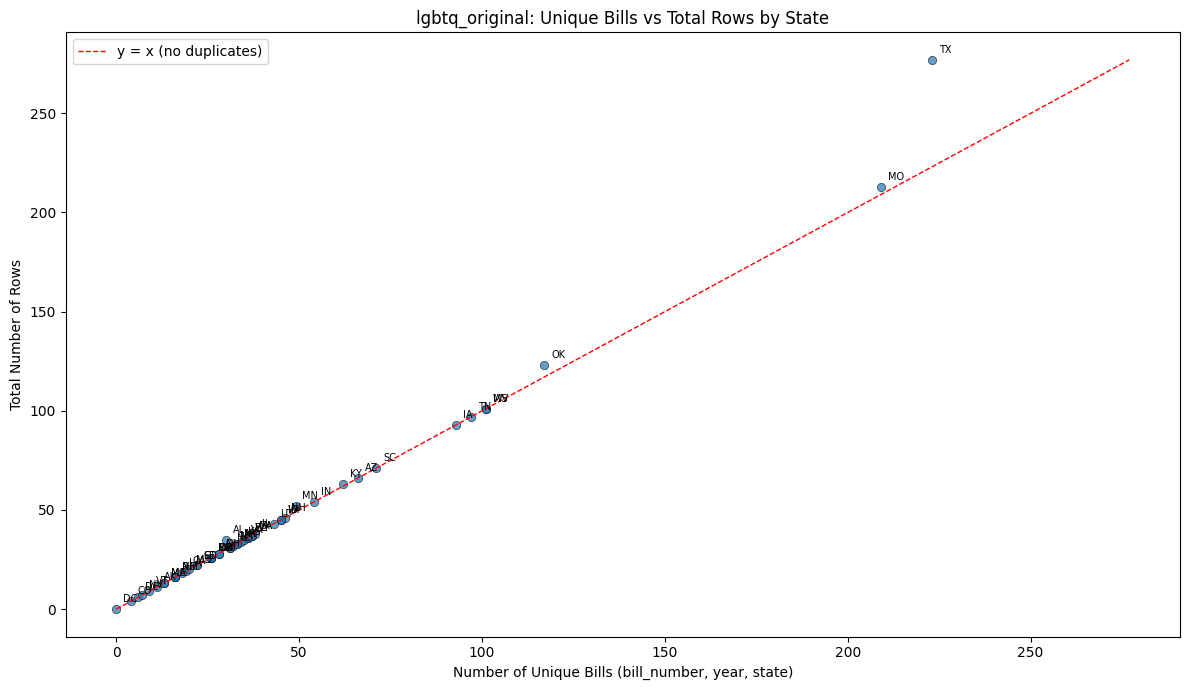

In [14]:
plot_unique_vs_total(lgbtq_original, title="lgbtq_original: Unique Bills vs Total Rows by State")

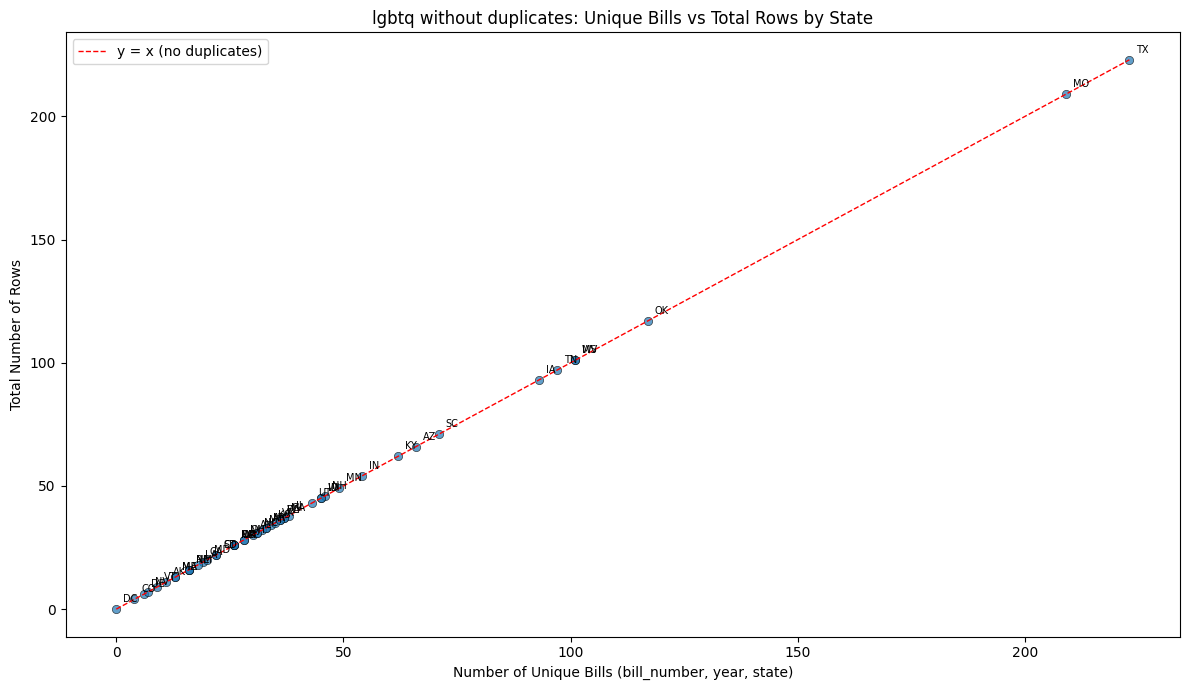

In [15]:
plot_unique_vs_total(lgbtq, title="lgbtq without duplicates: Unique Bills vs Total Rows by State")

Continue as usual.

In [16]:
lgbtq['label_id'] = 1

non_lgbtq = all_bills[~all_bills['bill_id'].isin(lgbtq['bill_id'])].sample(
    n=len(lgbtq) * 2,
    random_state=42
)
non_lgbtq['label_id'] = 0

df = pd.concat([lgbtq, non_lgbtq]).sample(frac=1, random_state=42)

In [17]:
print(df['text'].isna().sum())
print(df['text'].dtype)
print(df['text'].head(10).tolist())

0
object
['Relating To The Hawaii Symphony Orchestra.. Designates the Hawaii Symphony Orchestra as the State of Hawaii Symphony Orchestra. Exempts general fund appropriations to the State of Hawaii Symphony Orchestra from the requirements of chapter 42F, Hawaii Revised Statutes. Requires annual reports to the Legislature. Appropriates funds for general operating costs of the Orchestra and for deposit into the State of Hawaii Endowment Fund. Effective 7/1/3000. (HD1)', 'Education; sex education for public school students in this state before fifth grade; prohibit. A BILL to be entitled an Act to amend Chapter 2 of Title 20 of the Official Code of Georgia Annotated, relating to elementary and secondary education, so as to prohibit sex education for public school students in this state before fifth grade; to require the State Board of Education to approve age- and grade-appropriate content standards for sex education curricula; to provide for definitions; to provide for construction; to r

In [18]:
len(df)

6711

Deriving some meta-data...

In [19]:
def parse_party_counts(party_str):
    """Parse 'R | D | R | R' into party counts."""
    if pd.isna(party_str):
        return {'R': 0, 'D': 0, 'Other': 0}

    parties = [p.strip() for p in str(party_str).split('|')]
    counts = {
        'R': sum(1 for p in parties if p == 'R'),
        'D': sum(1 for p in parties if p == 'D'),
        'Other': sum(1 for p in parties if p not in ('R', 'D', ''))
    }
    return counts

# Apply and expand into columns
party_counts = df['sponsor_parties'].apply(parse_party_counts).apply(pd.Series)
df['r_sponsors'] = party_counts['R']
df['d_sponsors'] = party_counts['D']
df['other_sponsors'] = party_counts['Other']


# Derive the dominant party for each bill
def bill_dominant_party(row):
    if row['r_sponsors'] > row['d_sponsors']:
        return 'R'
    elif row['d_sponsors'] > row['r_sponsors']:
        return 'D'
    elif row['r_sponsors'] == 0 and row['d_sponsors'] == 0:
        return 'Other'
    else:
        return 'Bipartisan'


df['bill_dominant_party'] = df.apply(bill_dominant_party, axis=1)

In [58]:
# Compute state-year political profiles (aligned with NB03 and SageMaker)

df['_passed'] = df['status'].isin([4])

state_year_profiles = df.groupby(['state', 'year']).agg(
    total_bills=('bill_id', 'count'),
    r_sponsored_bills=('bill_dominant_party', lambda x: (x == 'R').sum()),
    d_sponsored_bills=('bill_dominant_party', lambda x: (x == 'D').sum()),
    bipartisan_bills=('bill_dominant_party',
                      lambda x: (x == 'Bipartisan').sum()),
    total_passed=('_passed', 'sum'),
    avg_sponsor_count=('sponsor_count', 'mean'),
    avg_action_count=('action_count', 'mean'),
).reset_index()

state_year_profiles['partisan_bills'] = (
    state_year_profiles['r_sponsored_bills'] +
    state_year_profiles['d_sponsored_bills']
)
state_year_profiles['state_r_sponsorship_ratio'] = (
    state_year_profiles['r_sponsored_bills'] /
    state_year_profiles['partisan_bills']
).fillna(0.5)

state_year_profiles['overall_pass_rate'] = (
    state_year_profiles['total_passed'] /
    state_year_profiles['total_bills']
)

# Pass rate gap
r_pass = df[df['bill_dominant_party'] == 'R'].groupby(['state', 'year'])['_passed'].mean()
d_pass = df[df['bill_dominant_party'] == 'D'].groupby(['state', 'year'])['_passed'].mean()
pass_gap = (r_pass - d_pass).reset_index().rename(columns={'_passed': 'pass_rate_gap'})
state_year_profiles = state_year_profiles.merge(pass_gap, on=['state', 'year'], how='left')
state_year_profiles['pass_rate_gap'] = state_year_profiles['pass_rate_gap'].fillna(0)

# 5-tier state lean (matches NB03 and SageMaker)
def classify_state_lean(row):
    r_ratio = row['state_r_sponsorship_ratio']
    gap = row['pass_rate_gap']
    if r_ratio > 0.7:
        return 'Lean R' if gap < -0.1 else 'Strong R'
    elif r_ratio > 0.55:
        if gap > 0.1:
            return 'Strong R'
        elif gap < -0.1:
            return 'Competitive'
        else:
            return 'Lean R'
    elif r_ratio < 0.3:
        return 'Lean D' if gap > 0.1 else 'Strong D'
    elif r_ratio < 0.45:
        if gap < -0.1:
            return 'Strong D'
        elif gap > 0.1:
            return 'Competitive'
        else:
            return 'Lean D'
    else:
        if gap > 0.1:
            return 'Lean R'
        elif gap < -0.1:
            return 'Lean D'
        return 'Competitive'

state_year_profiles['state_lean'] = state_year_profiles.apply(classify_state_lean, axis=1)

df.drop(columns=['_passed'], inplace=True)

print("\n--- State-Year Profile Sample ---")
cols = ['state', 'year', 'total_bills', 'state_r_sponsorship_ratio', 'pass_rate_gap', 'state_lean']
print(state_year_profiles[cols].head(10).to_string(index=False))


--- State-Year Profile Sample ---
state    year  total_bills  state_r_sponsorship_ratio  pass_rate_gap state_lean
   AK  2021.0            2                   0.000000       0.000000   Strong D
   AK  2022.0            4                   0.666667       0.000000     Lean R
   AK  2023.0            5                   1.000000       0.000000   Strong R
   AK  2024.0            3                   1.000000       0.000000   Strong R
   AK  2025.0            2                   1.000000       0.000000   Strong R
   AL  2021.0           16                   0.812500       0.461538   Strong R
   AL  2022.0           13                   0.916667      -0.454545     Lean R
   AL  2023.0           11                   0.909091       0.600000   Strong R
   AL  2024.0            9                   0.777778       0.285714   Strong R
   AL  2025.0           17                   0.937500       0.266667   Strong R


In [59]:
state_profile = (
    state_year_profiles
    .sort_values("year")
    .groupby("state")
    .tail(1)[["state", "year", "state_r_sponsorship_ratio", "pass_rate_gap", "state_lean"]]
)

In [60]:
print(state_profile.isna().sum())

state                        0
year                         0
state_r_sponsorship_ratio    0
pass_rate_gap                0
state_lean                   0
dtype: int64


In [61]:
print(state_profile[['state', 'state_r_sponsorship_ratio', 'state_lean']].head(10).to_string(index=False))

     state  state_r_sponsorship_ratio state_lean
USCongress                   0.380952     Lean D
        TX                   0.735099     Lean R
        AK                   1.000000   Strong R
        CA                   0.458333     Lean D
        AR                   0.880000   Strong R
        CO                   0.333333   Strong D
        WY                   1.000000   Strong R
        ND                   0.866667   Strong R
        NC                   0.575758   Strong R
        MT                   0.970588   Strong R


In [ ]:
# Drop old columns if they exist from a previous run/CSV to avoid _x/_y suffixes
for col in ['state_r_sponsorship_ratio', 'pass_rate_gap', 'state_lean', 'state_R_leaning', 'r_sponsorship_ratio']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

df = df.merge(
    state_profile[['state', 'state_r_sponsorship_ratio', 'pass_rate_gap', 'state_lean']],
    on='state',
    how='left'
)

In [63]:
lgbtq['year'] = lgbtq['session_year']
lgbtq['true_stance'] = lgbtq['label']


In [64]:
df['percent_yea'] = df['total_yea'] / (df['total_yea'] + df['total_nay'])
df['percent_nay'] = df['total_nay'] / (df['total_yea'] + df['total_nay'])

df['percent_yea'] = df['percent_yea'].fillna(0)
df['percent_nay'] = df['percent_nay'].fillna(0)

Defining train and test sets.

In [65]:

print(f"Total bills: {len(df)}")
print(f"  LGBTQ+:     {(df['label_id']==1).sum()}")
print(f"  Non-LGBTQ+: {(df['label_id']==0).sum()}")
print(f"\nSample text:\n{df['text'].iloc[0]}")

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label_id']
)
print(f"\nTrain: {len(train_df)} ({train_df['label_id'].mean():.1%} LGBTQ+)")
print(f"Test:  {len(test_df)} ({test_df['label_id'].mean():.1%} LGBTQ+)")

Total bills: 6711
  LGBTQ+:     2237
  Non-LGBTQ+: 4474

Sample text:
Relating To The Hawaii Symphony Orchestra.. Designates the Hawaii Symphony Orchestra as the State of Hawaii Symphony Orchestra. Exempts general fund appropriations to the State of Hawaii Symphony Orchestra from the requirements of chapter 42F, Hawaii Revised Statutes. Requires annual reports to the Legislature. Appropriates funds for general operating costs of the Orchestra and for deposit into the State of Hawaii Endowment Fund. Effective 7/1/3000. (HD1)

Train: 5368 (33.3% LGBTQ+)
Test:  1343 (33.4% LGBTQ+)


In [66]:
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = BertModel.from_pretrained(MODEL_NAME).to(device)

# Quick sanity check
test_inputs = tokenizer("An act prohibiting gender transition procedures for minors",
                       return_tensors="pt").to(device)
test_outputs = base_model(**test_inputs)
print(f"LegalBERT hidden size: {test_outputs.last_hidden_state.shape}")
# Should be [1, seq_len, 768]

LegalBERT hidden size: torch.Size([1, 10, 768])


In [29]:
# 1. Token length distribution across ALL bills
token_lengths = []
for _, row in df.iterrows():
    text = str(row['text']).strip()
    if text:
        toks = tokenizer(text)['input_ids']
        token_lengths.append(len(toks))

token_lengths = np.array(token_lengths)

print("TOKEN LENGTH DISTRIBUTION")
print("=" * 50)
print(f"  Min:    {token_lengths.min()}")
print(f"  25th:   {np.percentile(token_lengths, 25):.0f}")
print(f"  Median: {np.percentile(token_lengths, 50):.0f}")
print(f"  75th:   {np.percentile(token_lengths, 75):.0f}")
print(f"  95th:   {np.percentile(token_lengths, 95):.0f}")
print(f"  Max:    {token_lengths.max()}")

# How many bills get truncated at each max_len?
for ml in [128, 256, 512]:
    truncated = (token_lengths > ml).sum()
    pct = truncated / len(token_lengths) * 100
    print(f"\n  max_len={ml}: {truncated}/{len(token_lengths)} bills truncated ({pct:.1f}%)")


# 2. Show a few examples: short, median, long
sorted_idx = np.argsort(token_lengths)
examples = {
    'Shortest': sorted_idx[0],
    'Median':   sorted_idx[len(sorted_idx)//2],
    'Longest':  sorted_idx[-1],
}

for name, idx in examples.items():
    row = df.iloc[idx]
    text = str(row['text']).strip()
    toks = tokenizer(text)['input_ids']
    decoded = tokenizer.convert_ids_to_tokens(toks)

    print(f"\n{'='*50}")
    print(f"{name} bill: {row.get('state','')} {row.get('bill_number','')} ({len(toks)} tokens)")
    print(f"Raw: {text[:200]}{'...' if len(text)>200 else ''}")
    print(f"Tokens: {' '.join(decoded[:40])}{'...' if len(decoded)>40 else ''}")

Token indices sequence length is longer than the specified maximum sequence length for this model (608 > 512). Running this sequence through the model will result in indexing errors


TOKEN LENGTH DISTRIBUTION
  Min:    7
  25th:   32
  Median: 49
  75th:   79
  95th:   193
  Max:    9489

  max_len=128: 692/6711 bills truncated (10.3%)

  max_len=256: 202/6711 bills truncated (3.0%)

  max_len=512: 50/6711 bills truncated (0.7%)

Shortest bill: MO HB8 (7 tokens)
Raw: APPROPRIATION BILL. APPROPRIATION BILL
Tokens: [CLS] appropriation bill . appropriation bill [SEP]

Median bill: WA HB1439 (49 tokens)
Raw: Modifying motor vehicle and driver licensing laws to align with federal definitions, making technical corrections, and streamlining requirements.. Modifying motor vehicle and driver licensing laws to ...
Tokens: [CLS] modify ##ing motor vehicle and driver licensing laws to align with federal definitions , making technical corrections , and streamlin ##ing requirements . . modify ##ing motor vehicle and driver licensing laws to align with federal definitions , making...

Longest bill: OH HB96 (9489 tokens)
Raw: Make state operating appropriations for FY 2026-27. To 

In [30]:
class BillDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = []
        for _, row in dataframe.iterrows():
            text = str(row['text']).strip()
            if not text:
                continue
            encoded = tokenizer(
                text,
                return_tensors='pt',
                max_length=max_len,
                truncation=True,
                padding='max_length',
            )
            self.data.append({
                'input_ids': encoded['input_ids'].squeeze(0).to(device),
                'attention_mask': encoded['attention_mask'].squeeze(0).to(device),
                'label': torch.tensor(row['label_id'], dtype=torch.float32, device=device),
            })
        print(f"  Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


MAX_LEN = 256

print("Building train set...")
train_data = BillDataset(train_df, tokenizer, max_len=MAX_LEN)
print("Building test set...")
test_data = BillDataset(test_df, tokenizer, max_len=MAX_LEN)

Building train set...
  Loaded 5368 examples
Building test set...
  Loaded 1343 examples


In [31]:
class LegalBERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = torch.nn.Dropout(dropout)
        self.linear = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask=None):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        cls_output = bert_output[:, 0, :]
        cls_output = self.dropout(cls_output)
        logit = self.linear(cls_output)
        return torch.squeeze(logit)


model = LegalBERTClassifier(base_model).to(device)

# No class weighting needed — 2:1 ratio is mild enough
# loss_fn = torch.nn.BCEWithLogitsLoss()

# new loss_fn
# labels = torch.tensor([ex['label'] for ex in train_data], dtype=torch.float)  # adjust if needed
# n_pos = labels.sum()
# n_neg = labels.numel() - n_pos
# pos_weight = (n_neg / (n_pos + 1e-8)).to(device)   # ~ 97/3 = 32.33
# loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# print("pos_weight =", pos_weight.item())

# claude loss_fn
# Tune this: try 2.5, 3.0, 4.0
# 2.5 best for now (2.0 and 3.0 are objectively, all-around worse)
pos_weight = torch.tensor([3.0]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)



BATCH_SIZE = 8
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
batch = next(iter(train_loader))
out = model(batch['input_ids'], batch['attention_mask'])
loss = loss_fn(out, batch['label'])
print(f"Sanity check — output: {out.shape}, loss: {loss.item():.4f}")

Sanity check — output: torch.Size([8]), loss: 1.5519


In [32]:
def train_loop(dataloader, model, loss_fn, optimizer, reporting_interval=50):
    model.train()
    epoch_loss, total_batches = 0, 0

    for batch_idx, data in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = model(data['input_ids'], data['attention_mask'])
        loss = loss_fn(outputs, data['label'])
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total_batches += 1

        if (batch_idx + 1) % reporting_interval == 0:
            print(
                f"  Batch {batch_idx + 1}: avg loss = {epoch_loss / total_batches:.4f}")

    print(f"  Train loss: {epoch_loss / max(total_batches, 1):.4f}")


def eval_loop(dataloader, model, loss_fn):
    model.eval()
    test_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for data in dataloader:
            outputs = model(data['input_ids'], data['attention_mask'])
            test_loss += loss_fn(outputs, data['label']).item()

            preds = (torch.sigmoid(outputs) >= THRESHOLD).float()  # replace torch.round(...)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data['label'].cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(
        f"  Test loss: {test_loss / len(dataloader):.4f}, Accuracy: {100 * accuracy:.1f}%")
    print("\n" + classification_report(
        all_labels, all_preds,
        target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
    ))

In [34]:
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

print("Phase 1: Classifier head only\n")
for epoch in range(3):
    print(f"Epoch {epoch + 1}/3")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

# Phase 2: Unfreeze last 2 BERT layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Phase 2: Fine-tuning last 2 layers\n")
for epoch in range(2):
    print(f"Epoch {epoch + 1}/2")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

print("Done!")

Phase 1: Classifier head only

Epoch 1/3
  Batch 50: avg loss = 1.0837
  Batch 100: avg loss = 1.0881
  Batch 150: avg loss = 1.0875
  Batch 200: avg loss = 1.0849
  Batch 250: avg loss = 1.0784
  Batch 300: avg loss = 1.0745
  Batch 350: avg loss = 1.0718
  Batch 400: avg loss = 1.0673
  Batch 450: avg loss = 1.0627
  Batch 500: avg loss = 1.0590
  Batch 550: avg loss = 1.0545
  Batch 600: avg loss = 1.0477
  Batch 650: avg loss = 1.0434
  Train loss: 1.0417
  Test loss: 1.0216, Accuracy: 68.7%

              precision    recall  f1-score   support

  non-LGBTQ+      0.682     0.994     0.809       895
      LGBTQ+      0.868     0.074     0.136       448

    accuracy                          0.687      1343
   macro avg      0.775     0.534     0.472      1343
weighted avg      0.744     0.687     0.584      1343


Epoch 2/3
  Batch 50: avg loss = 1.0029
  Batch 100: avg loss = 0.9996
  Batch 150: avg loss = 1.0077
  Batch 200: avg loss = 1.0080
  Batch 250: avg loss = 0.9978
  Batc

In [35]:
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for data in test_loader:
        outputs = model(data['input_ids'], data['attention_mask'])
        # Apply sigmoid to convert logits → probabilities
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(data['label'].cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

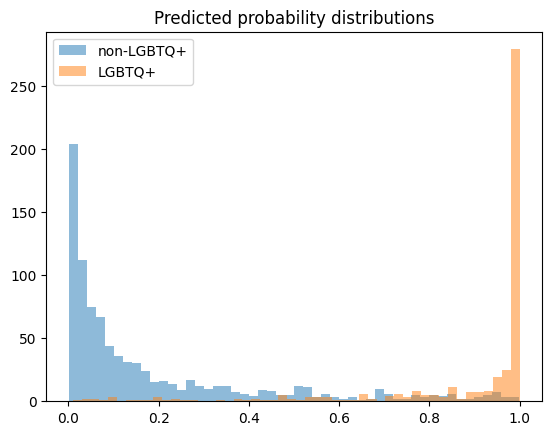

In [36]:
plt.hist(all_probs[all_labels==0], bins=50, alpha=0.5, label='non-LGBTQ+')
plt.hist(all_probs[all_labels==1], bins=50, alpha=0.5, label='LGBTQ+')
plt.legend()
plt.title("Predicted probability distributions")
plt.show()

In [ ]:
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.3f}")

# Compare thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (all_probs >= t).astype(int)
    print(f"\nThreshold = {t}:")
    print(classification_report(all_labels, preds,
          target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3))

Best F1 threshold: 0.711

Threshold = 0.3:
              precision    recall  f1-score   support

  non-LGBTQ+      0.972     0.789     0.871       895
      LGBTQ+      0.694     0.955     0.804       448

    accuracy                          0.844      1343
   macro avg      0.833     0.872     0.837      1343
weighted avg      0.879     0.844     0.849      1343


Threshold = 0.4:
              precision    recall  f1-score   support

  non-LGBTQ+      0.969     0.841     0.901       895
      LGBTQ+      0.749     0.946     0.836       448

    accuracy                          0.876      1343
   macro avg      0.859     0.894     0.869      1343
weighted avg      0.896     0.876     0.879      1343


Threshold = 0.5:
              precision    recall  f1-score   support

  non-LGBTQ+      0.957     0.876     0.915       895
      LGBTQ+      0.788     0.922     0.850       448

    accuracy                          0.891      1343
   macro avg      0.873     0.899     0.882      

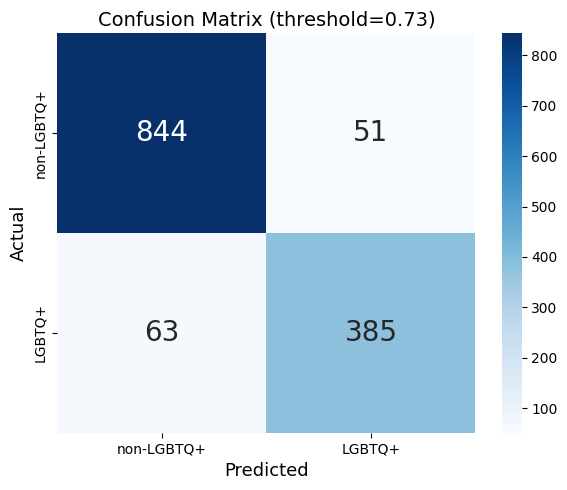

              precision    recall  f1-score   support

  non-LGBTQ+      0.931     0.943     0.937       895
      LGBTQ+      0.883     0.859     0.871       448

    accuracy                          0.915      1343
   macro avg      0.907     0.901     0.904      1343
weighted avg      0.915     0.915     0.915      1343



In [ ]:
# 0.6 puts the accuracy > 90% while putting FP rate at ~3.3%. Seems like the right

all_preds = (all_probs >= THRESHOLD).astype(int)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-LGBTQ+', 'LGBTQ+'],
            yticklabels=['non-LGBTQ+', 'LGBTQ+'],
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()

print(classification_report(
    all_labels, all_preds,
    target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
))

### Checking duplicate rows
These duplicate rows were EXCLUDED from the previous training or the testing sets as the ACLU bills had multiple matches in the legiscan database according to bill_number, year, and state. Now, we will use our own Legal-BERT model to classify them and save as a final matched_lgbtq_bills.csv (rather than the previous matched_lgbtq_bills_with_duplicates.csv)

In [39]:
dup_scored = lgbtq_duplicates

In [40]:
dup_scored.columns

Index(['state', 'bill_id', 'session_id', 'bill_number', 'status',
       'status_desc', 'status_date', 'title', 'description', 'committee_id',
       'committee', 'last_action_date', 'last_action', 'url', 'state_link',
       'sponsor_names', 'sponsor_parties', 'primary_sponsor', 'sponsor_count',
       'action_count', 'last_history_action', 'document_count', 'document_id',
       'document_type', 'document_url', 'rollcall_count', 'total_yea',
       'total_nay', 'year', 'r_sponsors', 'd_sponsors', 'other_sponsors',
       'bill_dominant_party', 'state_lean', 'state_r_sponsorship_ratio',
       'pass_rate_gap', 'overall_pass_rate', 'session_year', 'label',
       'label_source', 'issues', 'issue_categories', 'text'],
      dtype='object')

In [41]:
print(f"dup_scored bill_id dtype:    {dup_scored['bill_id'].dtype}")
print(f"all_bills_original bill_id dtype:  {all_bills_original['bill_id'].dtype}")

dup_scored bill_id dtype:    int64
all_bills_original bill_id dtype:  int64


In [44]:
matched = all_bills_original[all_bills_original['bill_id'].isin(dup_scored['bill_id'])]
print(f"Matched rows in all_bills_original: {len(matched)}")
print(f"text null in matched rows: {matched['text'].isna().sum()}")
print(f"\nSample matched texts:")
print(matched['text'].head(10).tolist())

Matched rows in all_bills_original: 119
text null in matched rows: 0

Sample matched texts:
['Sentencing standards, to provide for resentencing of certain individuals convicted of nonviolent offenses, procedure for resentencing, Sec. 12-25-34.3 added.. Sentencing standards, to provide for resentencing of certain individuals convicted of nonviolent offenses, procedure for resentencing, Sec. 12-25-34.3 added.', "Community Development District, adjust rate of taxation on sale of alcholic beverages, Sec. 35-8B-1 am'd.. Community Development District, adjust rate of taxation on sale of alcholic beverages, Sec. 35-8B-1 am'd.", 'U.S. Congressional, districts redrawn, Sec. 17-14-70 repealed; Sec. 17-14-70 added. U.S. Congressional, districts redrawn, Sec. 17-14-70 repealed; Sec. 17-14-70 added', 'Public contracts, exemption from certain bid requirements for certain educational entities providing meals under the Child Nutrition Program, Secs. 16-13B-2.1, 41-16-51.2 added.. Public contracts, exe

In [45]:
# BillDataset requires a label_id column — use a placeholder since we don't know true labels
dup_scored['label_id'] = -1

print("Building duplicate bills dataset...")
dup_data = BillDataset(dup_scored, tokenizer, max_len=MAX_LEN)
dup_loader = DataLoader(dup_data, batch_size=BATCH_SIZE, shuffle=False)

# Run predictions
model.eval()
dup_probs = []

with torch.no_grad():
    for data in dup_loader:
        outputs = model(data['input_ids'], data['attention_mask'])
        probs = torch.sigmoid(outputs)
        dup_probs.extend(probs.cpu().numpy())

dup_probs = np.array(dup_probs)

# Attach probabilities back to dup_scored
non_empty_mask = dup_scored['text'].str.strip().astype(bool)
dup_scored.loc[non_empty_mask, 'relevance_prob']     = dup_probs
dup_scored.loc[non_empty_mask, 'predicted_relevant'] = (dup_probs >= THRESHOLD).astype(int)

print(f"\nDuplicate rows scored: {len(dup_probs)}")
print(f"Predicted relevant:    {(dup_probs >= THRESHOLD).sum()}")
print(f"\nProbability distribution:")
print(pd.Series(dup_probs).describe())

Building duplicate bills dataset...
  Loaded 119 examples

Duplicate rows scored: 119
Predicted relevant:    54

Probability distribution:
count    119.000000
mean       0.544757
std        0.406474
min        0.004564
25%        0.103129
50%        0.586327
75%        0.989680
max        0.999748
dtype: float64


In [46]:
# ── Duplicate-pair disagreement analysis ──────────────────────────────────────
# Assumes: lgbtq_duplicates, model, tokenizer, THRESHOLD, MAX_LEN, device
# are all in scope from earlier cells.

model.eval()

def get_relevance_prob(text):
    """Run a single text through the trained LegalBERT and return P(LGBTQ+)."""
    enc = tokenizer(
        str(text).strip(),
        return_tensors='pt',
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length',
    ).to(device)
    with torch.no_grad():
        logit = model(enc['input_ids'], enc['attention_mask'])
        prob = torch.sigmoid(logit).item()
    return prob

# Score every duplicate row
dup_scored['relevance_prob'] = dup_scored['text'].apply(get_relevance_prob)
dup_scored['predicted_relevant'] = (dup_scored['relevance_prob'] >= THRESHOLD).astype(int)

# ── Pair-level disagreement ────────────────────────────────────────────────────
# Group by the shared key and check if predictions differ within any group
key_cols = ['bill_number', 'year', 'state']

group_stats = (
    dup_scored
    .groupby(key_cols)
    .agg(
        n_rows             = ('predicted_relevant', 'count'),
        n_predicted_relevant = ('predicted_relevant', 'sum'),
        prob_min           = ('relevance_prob', 'min'),
        prob_max           = ('relevance_prob', 'max'),
        prob_mean          = ('relevance_prob', 'mean'),
    )
    .reset_index()
)

# A group "disagrees" if it has at least one relevant AND one non-relevant prediction
group_stats['disagreement'] = (
    (group_stats['n_predicted_relevant'] > 0) &
    (group_stats['n_predicted_relevant'] < group_stats['n_rows'])
)
group_stats['prob_spread'] = group_stats['prob_max'] - group_stats['prob_min']

n_groups      = len(group_stats)
n_disagree    = group_stats['disagreement'].sum()
n_all_relevant   = (group_stats['n_predicted_relevant'] == group_stats['n_rows']).sum()
n_none_relevant  = (group_stats['n_predicted_relevant'] == 0).sum()

print(f"Duplicate bill groups:          {n_groups}")
print(f"  All rows predicted relevant:  {n_all_relevant}  ({n_all_relevant/n_groups:.1%})")
print(f"  All rows predicted irrelevant:{n_none_relevant}  ({n_none_relevant/n_groups:.1%})")
print(f"  Disagreeing groups:           {n_disagree}  ({n_disagree/n_groups:.1%})")

# ── Show disagreeing pairs ─────────────────────────────────────────────────────
disagreeing_keys = group_stats.loc[group_stats['disagreement'], key_cols]
disagreeing_rows = dup_scored.merge(disagreeing_keys, on=key_cols)

print(f"\nRows involved in disagreeing pairs: {len(disagreeing_rows)}")
print("\nSample disagreeing pairs (sorted by bill):")
display(
    disagreeing_rows[key_cols + ['text', 'relevance_prob', 'predicted_relevant']]
    .sort_values(key_cols)
    .head(20)
)


Duplicate bill groups:          46
  All rows predicted relevant:  6  (13.0%)
  All rows predicted irrelevant:9  (19.6%)
  Disagreeing groups:           31  (67.4%)

Rows involved in disagreeing pairs: 82

Sample disagreeing pairs (sorted by bill):


,bill_number,year,state,text,relevance_prob,predicted_relevant
0,HB1,2021.0,AL,"Sentencing standards, to provide for resentenc...",0.068030,0
2,HB1,2021.0,AL,"U.S. Congressional, districts redrawn, Sec. 17...",0.209634,0
5,HB1,2021.0,AL,Vulnerable Child Compassion and Protection Act...,0.998338,1
26,HB10,2021.0,TX,Relating to the regulation by a municipality o...,0.844428,1
30,HB10,2021.0,TX,Relating to requiring public school students t...,0.999423,1
33,HB10,2021.0,TX,Relating to the governance of the Public Utili...,0.040695,0
18,HB1011,2023.0,OK,Legacy Capital Financing Fund; Office of Manag...,0.102783,0
20,HB1011,2023.0,OK,Public health and safety; defining terms; heal...,0.996858,1
22,HB1011,2023.0,OK,Public finance; 2023 Inflation Relief Fund.. P...,0.103474,0
45,HB120,2025.0,TX,Relating to a temporary reduction in the maxim...,0.035623,0


In [47]:
# import textwrap
# from itertools import zip_longest

# COL_WIDTH = 70

# for key, group in dup_scored.groupby(key_cols):
#     print(f"\n{'='*COL_WIDTH*len(group)}")
#     print(f"bill_number={key[0]}  year={key[1]}  state={key[2]}  ({len(group)} rows)")
#     print(f"{'='*COL_WIDTH*len(group)}")

#     # Print header with relevance score for each row
#     headers = [
#         f"Row {i+1} | prob={row['relevance_prob']:.3f} | predicted={'RELEVANT' if row['predicted_relevant'] else 'NOT RELEVANT'}"
#         for i, (_, row) in enumerate(group.iterrows())
#     ]
#     print('  |  '.join(h.ljust(COL_WIDTH) for h in headers))
#     print('-' * COL_WIDTH * len(group))

#     # Wrap each row's text into lines of COL_WIDTH
#     wrapped = [textwrap.wrap(str(row['text']), width=COL_WIDTH) for _, row in group.iterrows()]

#     # Print columns side by side
#     for lines in zip_longest(*wrapped, fillvalue=''):
#         print('  |  '.join(line.ljust(COL_WIDTH) for line in lines))

# print(f"\nTotal duplicate groups: {dup_scored.groupby(key_cols).ngroups}")

Dropping rows out of the duplicate bills that scored low on relevance to LGBTQ issues:

In [48]:
# Get bill_ids that scored below threshold
irrelevant_bill_ids = set(dup_scored[dup_scored['relevance_prob'] < THRESHOLD]['bill_id'])

print(f"Bill IDs scoring below threshold: {len(irrelevant_bill_ids)}")
print(f"lgbtq_original shape before: {lgbtq_original.shape}")

# Remove those bill_ids from lgbtq_original
lgbtq_original = lgbtq_original[~lgbtq_original['bill_id'].isin(irrelevant_bill_ids)]

print(f"lgbtq_original shape after:  {lgbtq_original.shape}")


Bill IDs scoring below threshold: 65
lgbtq_original shape before: (2310, 43)
lgbtq_original shape after:  (2245, 43)


Saving the final version of matched_lgbtq_bills.csv:

In [50]:
# Save
lgbtq_original.to_csv('../../datasources/final-outputs/matched_lgbtq_bills.csv', index=False)
print("Saved to matched_lgbtq_bills.csv")

Saved to matched_lgbtq_bills.csv


Saving Legal-BERT model:

In [53]:
import os, json
from pathlib import Path

SAVE_DIR = Path("../models/lgbtq_relevance_legalbert_v1")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1) save tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# 2) save model weights + small metadata needed to rebuild the module
ckpt = {
    "model_state_dict": model.state_dict(),
    "base_model_name": MODEL_NAME,      # e.g. 'nlpaueb/legal-bert-base-uncased'
    "hidden_size": 768,
    "dropout": 0.3,
}
torch.save(ckpt, SAVE_DIR / "relevance_model_v1.pt")

print(f"Saved relevance model to: {SAVE_DIR.resolve()}")

Saved relevance model to: /Users/ambroquach/Desktop/UC-BERKELEY/DATASCI-210/CAPSTONE-PROJECT/arc-radius-api/pipeline/models/lgbtq_relevance_legalbert_v1


In [68]:
all_preds

array([0, 0, 0, ..., 0, 1, 0])

## 2. Stance Classifier

In [69]:
train_df.columns

Index(['state', 'bill_id', 'session_id', 'bill_number', 'status',
       'status_desc', 'status_date', 'title', 'description', 'committee_id',
       'committee', 'last_action_date', 'last_action', 'url', 'state_link',
       'sponsor_names', 'sponsor_parties', 'primary_sponsor', 'sponsor_count',
       'action_count', 'last_history_action', 'document_count', 'document_id',
       'document_type', 'document_url', 'rollcall_count', 'total_yea',
       'total_nay', 'year', 'r_sponsors', 'd_sponsors', 'other_sponsors',
       'bill_dominant_party', 'state_lean_x', 'state_r_sponsorship_ratio_x',
       'pass_rate_gap_x', 'overall_pass_rate', 'session_year', 'label',
       'label_source', 'issues', 'issue_categories', 'text', 'label_id',
       'state_R_leaning', 'state_r_sponsorship_ratio_y', 'percent_yea',
       'percent_nay', 'state_r_sponsorship_ratio', 'pass_rate_gap_y',
       'state_lean_y', 'true_stance', 'is_lgbtq'],
      dtype='object')

In [70]:
train_df['label']

398            NaN
3451       harmful
2183           NaN
3279           NaN
2042           NaN
           ...    
1672    supportive
2219       harmful
2570    supportive
4506           NaN
3793           NaN
Name: label, Length: 5368, dtype: object

In [71]:
# Stance features (aligned with SageMaker — 7 features)
STATE_LEAN_ORDINAL = {
    'Strong D': 0, 'Lean D': 1, 'Competitive': 2, 'Lean R': 3, 'Strong R': 4
}

features = [
    'state_r_sponsorship_ratio',
    # 'state_lean',
    'bill_dominant_party',
    'percent_nay',
    'r_sponsors',
    'd_sponsors',
    'other_sponsors',
]

train_df['true_stance'] = train_df['label']
train_df['is_lgbtq'] = train_df['label_id']

# Select a subset of columns
df_subset = train_df.loc[
          train_df['is_lgbtq'] == 1,
          features + ['true_stance']
      ].copy()

df_subset['true_stance'] = (df_subset['true_stance'] == 'harmful').astype(int)

if 'bill_dominant_party' in df_subset.columns:
    df_subset['bill_dominant_party'] = (df_subset['bill_dominant_party'] == 'R').astype(int)

# df_subset['state_lean'] = df_subset['state_lean'].map(STATE_LEAN_ORDINAL).fillna(2).astype(int)

print(df_subset)

      state_r_sponsorship_ratio  bill_dominant_party  percent_nay  r_sponsors  \
3451                   0.914894                    1     0.000000           1   
2461                   0.375000                    1     0.000000           1   
536                    0.735099                    1     0.000000          43   
1835                   0.475000                    0     0.000000           2   
6256                   1.000000                    1     0.148148           1   
...                         ...                  ...          ...         ...   
831                    1.000000                    1     0.263441          20   
5963                   0.326531                    0     0.000000           0   
1672                   0.458333                    0     0.212670           0   
2219                   0.735099                    1     0.366667           4   
2570                   0.475000                    0     0.310606           1   

      d_sponsors  other_spo

In [72]:
# test version

test_df['true_stance'] = test_df['label']
test_df['is_lgbtq'] = test_df['label_id']

# Select a subset of columns
df_subset_test = test_df.loc[
          test_df['is_lgbtq'] == 1,
          features + ['true_stance']
      ].copy()

df_subset_test['true_stance'] = (df_subset_test['true_stance'] == 'harmful').astype(int)

if 'bill_dominant_party' in df_subset_test.columns:
    df_subset_test['bill_dominant_party'] = (df_subset_test['bill_dominant_party'] == 'R').astype(int)

# df_subset_test['state_lean'] = df_subset_test['state_lean'].map(STATE_LEAN_ORDINAL).fillna(2).astype(int)

print(df_subset_test)

      state_r_sponsorship_ratio  bill_dominant_party  percent_nay  r_sponsors  \
2669                   0.142857                    1     0.000000           1   
4119                   0.914894                    1     0.000000           1   
2614                   0.735099                    1     0.000000          25   
3726                   0.560000                    0     0.357143           0   
3438                   1.000000                    1     0.000000           1   
...                         ...                  ...          ...         ...   
1194                   0.880000                    1     0.064516           3   
6                      1.000000                    1     0.000000           1   
715                    0.554054                    1     0.000000           1   
6340                   1.000000                    1     0.000000           1   
4812                   1.000000                    1     0.000000           2   

      d_sponsors  other_spo

In [73]:
# fix so train are the same
# X = df_subset.drop(columns='true_stance')
# y = df_subset['true_stance']

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,          # 20% test set
#     stratify=y,             # keeps harmful/supportive proportions
#     random_state=42
# )

X_train = df_subset.drop(columns='true_stance')
y_train = df_subset['true_stance']

X_test = df_subset_test.drop(columns='true_stance')
y_test = df_subset_test['true_stance']


In [74]:
print(df_subset.isna().sum())

state_r_sponsorship_ratio    0
bill_dominant_party          0
percent_nay                  0
r_sponsors                   0
d_sponsors                   0
other_sponsors               0
true_stance                  0
dtype: int64


In [75]:
print(df_subset_test.isna().sum())

state_r_sponsorship_ratio    0
bill_dominant_party          0
percent_nay                  0
r_sponsors                   0
d_sponsors                   0
other_sponsors               0
true_stance                  0
dtype: int64


In [76]:
model_2 = LogisticRegression(max_iter=500) # max_iter = 1000 originally
# , class_weight='balanced'

model_2.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [77]:
y_pred = model_2.predict(X_test)

print('New linear stance model_2 using state, sponsor, and voting metadata:\n')
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['supportive', 'harmful']))

New linear stance model_2 using state, sponsor, and voting metadata:

Accuracy: 0.9486607142857143
              precision    recall  f1-score   support

  supportive       0.86      0.63      0.73        49
     harmful       0.96      0.99      0.97       399

    accuracy                           0.95       448
   macro avg       0.91      0.81      0.85       448
weighted avg       0.95      0.95      0.95       448



In [ ]:
# print('Old binary stance model using only dominant party:\n')

# y_pred_prev = np.where(df_subset['bill_dominant_party'] == 1, 1, 0)

# y_true = df_subset['true_stance']

# print("Accuracy:", accuracy_score(y_true, y_pred_prev))
# print(classification_report(y_true, y_pred_prev, target_names=['supportive', 'harmful']))

In [78]:
len(X_test)

448

In [79]:
len(all_preds)

1343

#Cumulative Test Accuracy Report
Results from both models hooked together

In [80]:
# Attach predictions to dataframe
test_df['relevant_pred'] = all_preds

# Select only bills predicted as LGBTQ-relevant
df_subset_test_final = test_df.loc[
    test_df['relevant_pred'] == 1,
    features + ['true_stance']
].copy()

# Convert stance to binary target
df_subset_test_final['true_stance'] = (df_subset_test_final['true_stance'] == 'harmful').astype(int)

# Convert bill_dominant_party if present
if 'bill_dominant_party' in df_subset_test_final.columns:
    df_subset_test_final['bill_dominant_party'] = (df_subset_test_final['bill_dominant_party'] == 'R').astype(int)

# df_subset_test_final['state_lean'] = df_subset_test_final['state_lean'].map(STATE_LEAN_ORDINAL).fillna(2).astype(int)

print(df_subset_test_final)

      state_r_sponsorship_ratio  bill_dominant_party  percent_nay  r_sponsors  \
2669                   0.142857                    1     0.000000           1   
3438                   1.000000                    1     0.000000           1   
1195                   0.588235                    1     0.000000          11   
3123                   0.866667                    1     0.517986          10   
6018                   1.000000                    1     0.000000           1   
...                         ...                  ...          ...         ...   
1671                   0.828571                    1     0.000000          11   
767                    0.750000                    1     0.000000           5   
6                      1.000000                    1     0.000000           1   
715                    0.554054                    1     0.000000           1   
5562                   0.914894                    1     0.132353           1   

      d_sponsors  other_spo

In [81]:
test_df['true_cumulative_label'] = np.where(
    test_df['is_lgbtq'] == True,
    test_df['true_stance'],
    "not applicable"
)

In [82]:
X_test_final = df_subset_test_final.drop(columns='true_stance')
y_test_final = df_subset_test_final['true_stance']

stance_preds = model_2.predict(X_test_final)

In [83]:
test_df['pred_cumulative_label'] = "not applicable"

# Fill in stance predictions for relevant bills
test_df.loc[test_df['relevant_pred'] == 1, 'pred_cumulative_label'] = stance_preds

test_df['pred_cumulative_label'] = test_df['pred_cumulative_label'].replace({
    1: 'harmful',
    0: 'supportive'
})

In [84]:
print(
    test_df[['relevant_pred','pred_cumulative_label']].head(10)
)

      relevant_pred pred_cumulative_label
6283              0        not applicable
3690              0        not applicable
3098              0        not applicable
643               0        not applicable
4572              0        not applicable
94                0        not applicable
2669              1               harmful
3373              0        not applicable
4119              0        not applicable
3299              0        not applicable


In [85]:
print('Combination Accuracy Assessment of relevance and stance models:\n')
print("Accuracy:", accuracy_score(test_df['true_cumulative_label'],
        test_df['pred_cumulative_label']))
print(classification_report(
        test_df['true_cumulative_label'],
        test_df['pred_cumulative_label']
    ))

Combination Accuracy Assessment of relevance and stance models:

Accuracy: 0.9009679821295606
                precision    recall  f1-score   support

       harmful       0.88      0.86      0.87       399
not applicable       0.93      0.94      0.94       895
    supportive       0.49      0.47      0.48        49

      accuracy                           0.90      1343
     macro avg       0.77      0.76      0.76      1343
  weighted avg       0.90      0.90      0.90      1343



In [ ]:
# Combined CM
labels = ['harmful', 'supportive', 'not applicable']
cm = confusion_matrix(
    test_df['true_cumulative_label'],
    test_df['pred_cumulative_label'],
    labels=labels
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Combined Pipeline: Relevance + Stance')
plt.tight_layout()
plt.show()